# TP3 - Validacion de hipotesis

Este notebook complementa al principal (`TP3_Grupo_1.ipynb`). Aca trabajamos las cuatro hipotesis del trabajo:

1. Rentabilidad temporaria contra largo plazo en barrios turisticos.
2. Mayor precio por metro cuadrado no implica mayor rentabilidad.
3. Los amenities aumentan el precio de venta pero no el de alquiler.
4. La cercania al subte impacta en el precio por metro cuadrado.

Cargamos el checkpoint que dejo el notebook principal al cerrar la seccion 2 (enriquecimiento espacial).

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, spearmanr, pearsonr

SEED = 42
np.random.seed(SEED)

CHECKPOINT = '../data/processed/checkpoint_post_enriquecimiento.pkl'
KPIS = '../data/raw/dataframe_kpis.tsv'

df = pd.read_pickle(CHECKPOINT)
df_kpis = pd.read_csv(KPIS, sep='\t')
print(f'Propiedades cargadas: {len(df):,}')
print(f'Barrios con KPIs: {len(df_kpis):,}')


Propiedades cargadas: 51,992
Barrios con KPIs: 48


### Hipótesis 1. Rentabilidad temporaria contra largo plazo en barrios turísticos

Para esta comparación usamos el test de Mann-Whitney, que es no paramétrico y se banca que las rentabilidades no estén distribuidas normalmente. Para definir qué barrios son turísticos nos basamos en notas de turismo sobre Buenos Aires.

In [7]:
BARRIOS_TURISTICOS = ['Palermo', 'San Telmo', 'Recoleta', 'La Boca']

kpis = df_kpis.set_index('barrio_oficial') if 'barrio_oficial' in df_kpis.columns else df_kpis.copy()

kpis['es_turistico'] = kpis.index.isin(BARRIOS_TURISTICOS)

turisticos    = kpis[kpis['es_turistico']]
no_turisticos = kpis[~kpis['es_turistico']]

print('Hipótesis 1: rentabilidad neta temporaria mayor que la de largo plazo en barrios turísticos')
print('La hipótesis nula sostiene que la rentabilidad temporaria es menor o igual a la de largo plazo')
print('Trabajamos con un nivel de significancia del 5 por ciento')
print('\nBarrios turísticos analizados:', [b for b in BARRIOS_TURISTICOS if b in kpis.index])
print(f'\nMediana de la rentabilidad neta a largo plazo en barrios turísticos:   {turisticos["rent_neta_lp_pct"].median():.2f} por ciento')
print(f'Mediana de la rentabilidad neta temporaria en barrios turísticos:      {turisticos["rent_neta_temp_pct"].median():.2f} por ciento')

if len(turisticos) >= 2:
    stat, p = mannwhitneyu(
        turisticos['rent_neta_temp_pct'].dropna(),
        turisticos['rent_neta_lp_pct'].dropna(),
        alternative='greater'
    )
    print(f'\nEstadístico de Mann-Whitney: {stat:.2f}, p-valor: {p:.4f}')
    if p < 0.05:
        print('Rechazamos la hipótesis nula. La rentabilidad temporaria es significativamente mayor en los barrios turísticos.')
    else:
        print('No rechazamos la hipótesis nula. No hay evidencia suficiente de que la temporaria supere a la de largo plazo en los barrios turísticos.')
else:
    print('\nLa muestra es muy chica para correr el test. Interpretamos directamente las medianas.')

Hipótesis 1: rentabilidad neta temporaria mayor que la de largo plazo en barrios turísticos
La hipótesis nula sostiene que la rentabilidad temporaria es menor o igual a la de largo plazo
Trabajamos con un nivel de significancia del 5 por ciento

Barrios turísticos analizados: ['Palermo', 'San Telmo', 'Recoleta', 'La Boca']

Mediana de la rentabilidad neta a largo plazo en barrios turísticos:   6.00 por ciento
Mediana de la rentabilidad neta temporaria en barrios turísticos:      4.00 por ciento

Estadístico de Mann-Whitney: 3.50, p-valor: 0.9280
No rechazamos la hipótesis nula. No hay evidencia suficiente de que la temporaria supere a la de largo plazo en los barrios turísticos.


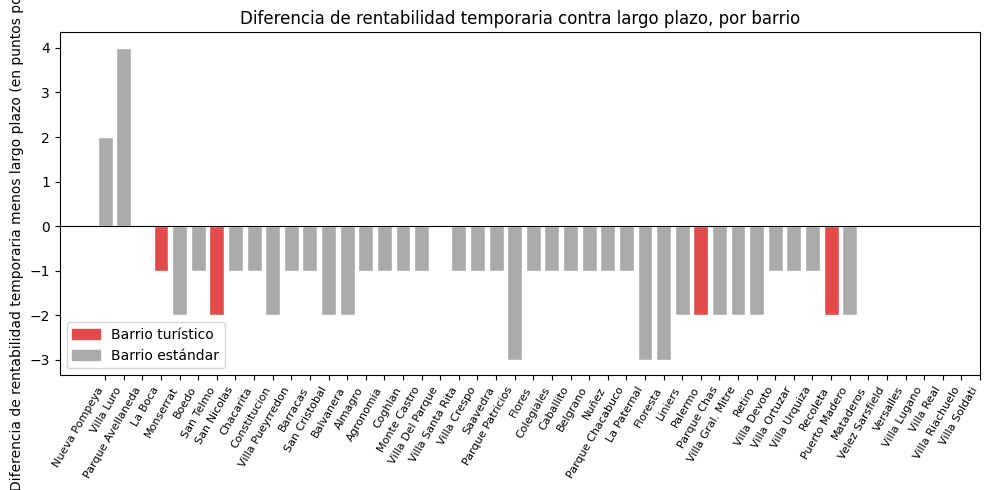

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
kpis_sorted = kpis.sort_values('rent_neta_temp_pct', ascending=False)
x = range(len(kpis_sorted))
colores = ['#E24B4A' if t else '#AAAAAA' for t in kpis_sorted['es_turistico']]
ax.bar(x, kpis_sorted['rent_neta_temp_pct'] - kpis_sorted['rent_neta_lp_pct'],
       color=colores, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(kpis_sorted.index, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Diferencia de rentabilidad temporaria menos largo plazo (en puntos porcentuales)')
ax.set_title('Diferencia de rentabilidad temporaria contra largo plazo, por barrio')
patch_t = mpatches.Patch(color='#E24B4A', label='Barrio turístico')
patch_n = mpatches.Patch(color='#AAAAAA', label='Barrio estándar')
ax.legend(handles=[patch_t, patch_n])
plt.tight_layout()
plt.show()

No llegamos a rechazar la hipótesis nula, así que no encontramos evidencia suficiente para afirmar que los barrios turísticos rinden más en alquiler temporario que en largo plazo. Una explicación posible es que con apenas cuatro barrios turísticos la muestra es muy chica para que un test como Mann-Whitney detecte la diferencia. Por ende, la conclusion no llega a ser muy fuerte.

### Hipótesis 2. Mayor precio por metro cuadrado no implica mayor rentabilidad

In [9]:
# La hipótesis nula sostiene que la correlación entre precio y rentabilidad es cero o positiva.
# La hipótesis alternativa sostiene que la correlación es negativa: los barrios caros rinden menos.

kpis = df_kpis.set_index('barrio_oficial') if 'barrio_oficial' in df_kpis.columns else df_kpis.copy()

# Usamos el precio mediano por metro cuadrado que ya viene calculado
h2 = kpis[['rent_neta_lp_pct', 'precio_m2_mediano']].dropna()

# Primer test: correlación de Spearman sobre todos los barrios
rho, p_rho = spearmanr(h2['precio_m2_mediano'], h2['rent_neta_lp_pct'])
# Como la alternativa es direccional (negativa), el p-valor unilateral es la mitad del bilateral
p_unilateral = p_rho / 2 if rho < 0 else 1 - p_rho / 2

print('Hipótesis 2: precio por metro cuadrado contra rentabilidad neta a largo plazo')
print('La hipótesis nula es que la correlación es mayor o igual a cero')
print('Trabajamos con un nivel de significancia del 5 por ciento')
print(f'\nCorrelación de Spearman: {rho:.3f}')
print(f'p-valor bilateral: {p_rho:.4f}, p-valor unilateral: {p_unilateral:.4f}')
if p_unilateral < 0.05 and rho < 0:
    print('Rechazamos la hipótesis nula. Hay una correlación negativa significativa: los barrios más caros rinden menos. Hipótesis 2 confirmada.')
elif p_rho < 0.05 and rho > 0:
    print('Rechazamos la hipótesis nula en sentido contrario: la correlación es positiva. La hipótesis 2 no se confirma.')
else:
    print('No rechazamos la hipótesis nula. No hay evidencia de correlación negativa significativa.')

# Segundo test: comparación entre los 10 barrios más caros y el resto, como complemento narrativo
N_TOP = 10
top_barrios  = h2.nlargest(N_TOP, 'precio_m2_mediano')
resto        = h2[~h2.index.isin(top_barrios.index)]

stat_mw, p_mw = mannwhitneyu(
    top_barrios['rent_neta_lp_pct'].dropna(),
    resto['rent_neta_lp_pct'].dropna(),
    alternative='less'
)
print(f'\nMann-Whitney entre los {N_TOP} barrios más caros y el resto')
print('La hipótesis nula es que los más caros rinden igual o más que el resto')
print(f'Estadístico: {stat_mw:.2f}, p-valor: {p_mw:.4f}')
if p_mw < 0.05:
    print(f'Rechazamos la hipótesis nula. Los {N_TOP} barrios más caros tienen una rentabilidad neta significativamente menor.')
else:
    print(f'No rechazamos la hipótesis nula. No hay diferencia significativa entre los {N_TOP} más caros y el resto.')

Hipótesis 2: precio por metro cuadrado contra rentabilidad neta a largo plazo
La hipótesis nula es que la correlación es mayor o igual a cero
Trabajamos con un nivel de significancia del 5 por ciento

Correlación de Spearman: -0.806
p-valor bilateral: 0.0000, p-valor unilateral: 0.0000
Rechazamos la hipótesis nula. Hay una correlación negativa significativa: los barrios más caros rinden menos. Hipótesis 2 confirmada.

Mann-Whitney entre los 10 barrios más caros y el resto
La hipótesis nula es que los más caros rinden igual o más que el resto
Estadístico: 58.00, p-valor: 0.0002
Rechazamos la hipótesis nula. Los 10 barrios más caros tienen una rentabilidad neta significativamente menor.


Para confirmar si los barrios con mayor precio por metro cuadrado realmente no son los de mayor rentabilidad, hicimos dos pruebas. Primero un test de Spearman sobre todos los barrios, que nos dio una correlación negativa significativa entre precio por metro cuadrado y rentabilidad.

Después tomamos los diez barrios más caros y los comparamos contra el resto, para ver si rinden menos. También rechazamos la hipótesis nula, así que hay evidencia para decir que esos barrios más caros tienen una rentabilidad menor.

Esto sugiere que, para alguien que esté buscando alta rentabilidad sin tener preferencia particular por un barrio, probablemente no recomendemos los más caros.

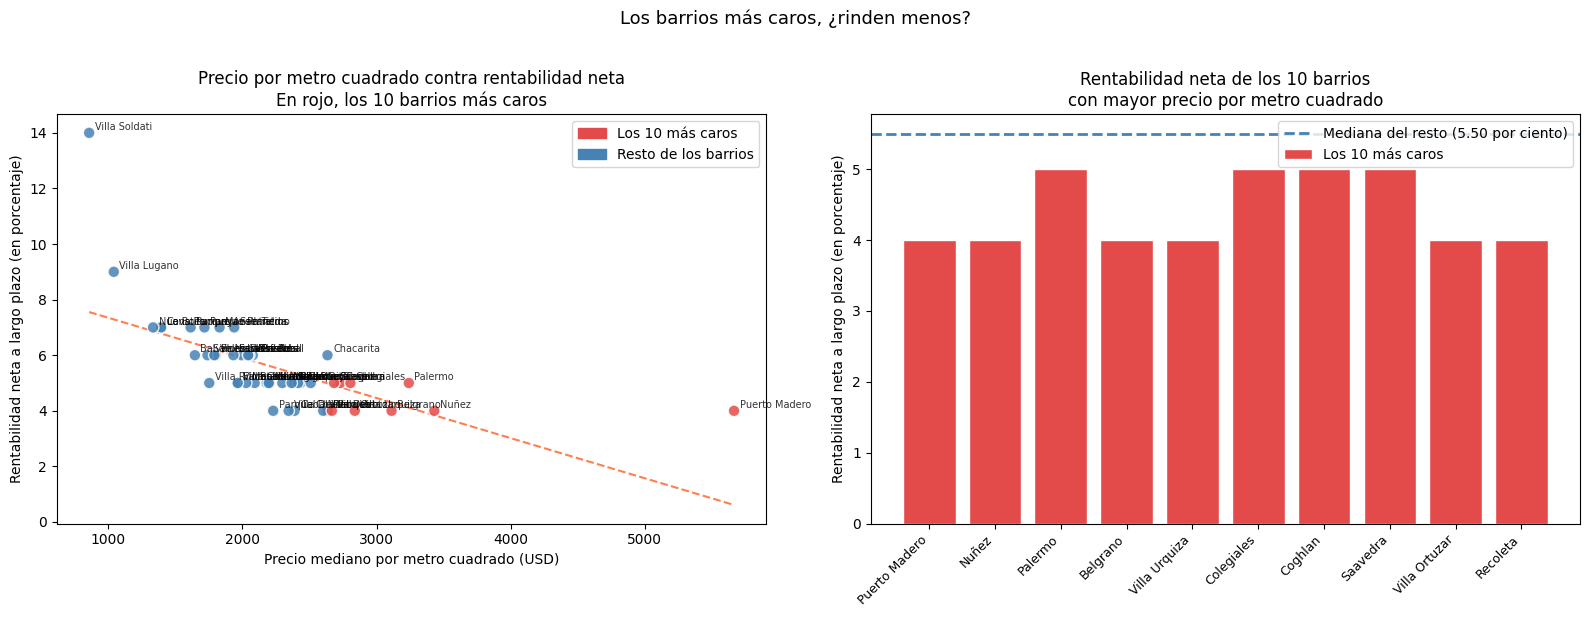

In [10]:
# Primer gráfico: dispersión con línea de tendencia para todos los barrios
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
colores_scatter = ['#E24B4A' if b in top_barrios.index else 'steelblue' for b in h2.index]
ax.scatter(h2['precio_m2_mediano'], h2['rent_neta_lp_pct'],
           color=colores_scatter, s=70, alpha=0.85, edgecolors='white', zorder=3)
for barrio, row in h2.iterrows():
    ax.annotate(barrio, (row['precio_m2_mediano'], row['rent_neta_lp_pct']),
                fontsize=7, alpha=0.8, xytext=(4, 2), textcoords='offset points')
xr = np.linspace(h2['precio_m2_mediano'].min(), h2['precio_m2_mediano'].max(), 100)
ax.plot(xr, np.poly1d(np.polyfit(h2['precio_m2_mediano'], h2['rent_neta_lp_pct'], 1))(xr),
        '--', color='coral', linewidth=1.5, label=f'Tendencia (correlación {rho:.2f})')
ax.set_xlabel('Precio mediano por metro cuadrado (USD)')
ax.set_ylabel('Rentabilidad neta a largo plazo (en porcentaje)')
ax.set_title('Precio por metro cuadrado contra rentabilidad neta\nEn rojo, los 10 barrios más caros')
patch_top  = mpatches.Patch(color='#E24B4A', label=f'Los {N_TOP} más caros')
patch_rest = mpatches.Patch(color='steelblue', label='Resto de los barrios')
ax.legend(handles=[patch_top, patch_rest])

# Segundo gráfico: barras de los 10 más caros contra la mediana del resto
ax2 = axes[1]
mediana_resto = resto['rent_neta_lp_pct'].median()
top_sorted = top_barrios.sort_values('precio_m2_mediano', ascending=False)

bars = ax2.bar(range(len(top_sorted)), top_sorted['rent_neta_lp_pct'],
               color='#E24B4A', edgecolor='white', label=f'Los {N_TOP} más caros')
ax2.axhline(mediana_resto, color='steelblue', linewidth=2, linestyle='--',
            label=f'Mediana del resto ({mediana_resto:.2f} por ciento)')
ax2.set_xticks(range(len(top_sorted)))
ax2.set_xticklabels(top_sorted.index, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Rentabilidad neta a largo plazo (en porcentaje)')
ax2.set_title(f'Rentabilidad neta de los {N_TOP} barrios\ncon mayor precio por metro cuadrado')
ax2.legend()

plt.suptitle('Los barrios más caros, ¿rinden menos?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

El primer gráfico muestra la tendencia negativa entre el precio por metro cuadrado y la rentabilidad neta. El segundo deja clara la diferencia que tienen los diez barrios más caros frente al resto en términos de rentabilidad.

### Hipótesis 3. Los amenities aumentan el precio de venta pero no el de alquiler

Comparamos con Mann-Whitney el precio por metro cuadrado entre propiedades con y sin cada amenity, para cada tipo de operación.

In [11]:
AMENITIES_H3 = ['pileta', 'gimnasio', 'balcon', 'baulera', 'parrilla', 'sum']
amenities_presentes = [a for a in AMENITIES_H3 if a in df.columns]

resultados_h3 = []
for amenity in amenities_presentes:
    for operacion in ['venta', 'alquiler', 'alquiler_temporal']:
        subset = df[(df['operacion'] == operacion) & df['precio_por_m2_usd'].notna()]
        con    = subset[subset[amenity] == 1]['precio_por_m2_usd']
        sin_am = subset[subset[amenity] == 0]['precio_por_m2_usd']
        if len(con) < 10 or len(sin_am) < 10:
            continue
        stat, p = mannwhitneyu(con, sin_am, alternative='greater')
        resultados_h3.append({
            'amenity': amenity,
            'operacion': operacion,
            'mediana_con': con.median(),
            'mediana_sin': sin_am.median(),
            'dif_%': (con.median() - sin_am.median()) / sin_am.median() * 100,
            'p_valor': p,
            'significativo': 'Sí' if p < 0.05 else 'No'
        })

df_h3 = pd.DataFrame(resultados_h3)
print('Hipótesis 3: impacto de los amenities sobre el precio por metro cuadrado, según el tipo de operación')
print(df_h3.to_string(index=False))

print('\nConclusión por amenity')
for amenity in amenities_presentes:
    fila_venta    = df_h3[(df_h3['amenity'] == amenity) & (df_h3['operacion'] == 'venta')]
    fila_alq      = df_h3[(df_h3['amenity'] == amenity) & (df_h3['operacion'] == 'alquiler')]
    fila_alq_temp = df_h3[(df_h3['amenity'] == amenity) & (df_h3['operacion'] == 'alquiler_temporal')]

    sig_venta    = (not fila_venta.empty)    and fila_venta['significativo'].values[0]    == 'Sí'
    sig_alq      = (not fila_alq.empty)      and fila_alq['significativo'].values[0]      == 'Sí'
    sig_alq_temp = (not fila_alq_temp.empty) and fila_alq_temp['significativo'].values[0] == 'Sí'

    # Venta contra alquiler tradicional
    if fila_venta.empty or fila_alq.empty:
        concl_lp = 'Sin datos suficientes'
    elif sig_venta and not sig_alq:
        concl_lp = 'Hipótesis confirmada: aumenta en venta pero no en alquiler tradicional'
    elif sig_venta and sig_alq:
        concl_lp = 'Aumenta en venta y también en alquiler tradicional'
    else:
        concl_lp = 'Hipótesis no confirmada: no aumenta significativamente en venta'

    # Venta contra alquiler temporario
    if fila_venta.empty or fila_alq_temp.empty:
        concl_temp = 'Sin datos suficientes'
    elif sig_venta and not sig_alq_temp:
        concl_temp = 'Hipótesis confirmada: aumenta en venta pero no en alquiler temporario'
    elif sig_venta and sig_alq_temp:
        concl_temp = 'Aumenta en venta y también en alquiler temporario'
    else:
        concl_temp = 'Hipótesis no confirmada: no aumenta significativamente en venta'

    print(f'\n{amenity}')
    print(f'  contra alquiler tradicional: {concl_lp}')
    print(f'  contra alquiler temporario:  {concl_temp}')

Hipótesis 3: impacto de los amenities sobre el precio por metro cuadrado, según el tipo de operación
 amenity         operacion  mediana_con  mediana_sin     dif_%       p_valor significativo
  pileta             venta  3365.116279  2342.599743 43.648794  0.000000e+00            Sí
  pileta          alquiler    17.163049    12.367491 38.775510  0.000000e+00            Sí
  pileta alquiler_temporal    21.093750    15.681782 34.511176 5.096952e-151            Sí
gimnasio             venta  3661.971831  2416.472868 51.542021  0.000000e+00            Sí
gimnasio          alquiler    20.000000    12.518930 59.758065  0.000000e+00            Sí
gimnasio alquiler_temporal    23.076923    16.129032 43.076923 6.277511e-153            Sí
  balcon             venta  2684.210526  2266.666667 18.421053 9.112425e-259            Sí
  balcon          alquiler    13.349038    12.619889  5.777778  1.798780e-32            Sí
  balcon alquiler_temporal    17.667845    16.405856  7.692308  1.709237e-12    

Para cerrar la hipótesis, miramos el patrón general que dejan los amenities testeados. Confirmamos que los amenities no solo aumentan el precio de venta, sino tambien el de alquiler temporal y a largo plazo. Cada amenity que testeamos —pileta, gimnasio, parrilla, SUM, balcón y baulera— resulta estadísticamente significativa en las tres modalidades de operación. El caso más llamativo es el del gimnasio, que suma 52 por ciento al precio de venta y 60 por ciento al precio de alquiler. Es decir, el alquiler captura incluso un poco más del premium que la venta.

Por ende, podemos concluir que recomendamos considerar pagar un precio mayor por un departamento con amenities ya que puede llegar ser redituable para ambos tipos de alquileres.

### Hipótesis 4. La cercanía al subte impacta en el precio por metro cuadrado

In [12]:
# Cada propiedad tiene su propia coordenada y su propia distancia al subte,
# así que el test trabaja con esa granularidad real y no con medianas por barrio.

subset_h4 = df[
    (df['operacion'] == 'venta') &
    df['precio_por_m2_usd'].notna() &
    df['dist_subte_km'].notna()
].copy()

rho_h4, p_h4 = spearmanr(subset_h4['dist_subte_km'], subset_h4['precio_por_m2_usd'])

print('Hipótesis 4: distancia al subte contra precio por metro cuadrado, en ventas en dólares, a nivel propiedad')
print(f'Cantidad de propiedades analizadas: {len(subset_h4):,}')
print(f'Correlación de Spearman: {rho_h4:.3f}, p-valor: {p_h4:.4g}')
if p_h4 < 0.05:
    if rho_h4 < 0:
        print('Rechazamos la hipótesis nula. A mayor distancia al subte, menor precio por metro cuadrado. Hipótesis 4 confirmada.')
    else:
        print('Rechazamos la hipótesis nula, pero con signo contrario al esperado: la correlación es positiva.')
else:
    print('No rechazamos la hipótesis nula. No hay correlación significativa con la distancia al subte.')

# Agrupamos por rangos de distancia para ver la relación de manera más intuitiva
bins = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 100]
labels = ['menos de 250 m', '250 a 500 m', '500 a 750 m', '750 m a 1 km',
          '1 a 1.5 km', '1.5 a 2 km', '2 a 3 km', 'más de 3 km']
subset_h4['bucket_subte'] = pd.cut(subset_h4['dist_subte_km'], bins=bins, labels=labels)
bucket_stats = (subset_h4.groupby('bucket_subte', observed=True)
                         .agg(n=('precio_por_m2_usd', 'size'),
                              precio_m2_mediano=('precio_por_m2_usd', 'median'),
                              precio_m2_p25=('precio_por_m2_usd', lambda s: s.quantile(0.25)),
                              precio_m2_p75=('precio_por_m2_usd', lambda s: s.quantile(0.75))))
print('\nPrecio por metro cuadrado en dólares según la distancia al subte, a nivel propiedad:')
print(bucket_stats.round(0).to_string())

Hipótesis 4: distancia al subte contra precio por metro cuadrado, en ventas en dólares, a nivel propiedad
Cantidad de propiedades analizadas: 24,974
Correlación de Spearman: 0.137, p-valor: 5.883e-105
Rechazamos la hipótesis nula, pero con signo contrario al esperado: la correlación es positiva.

Precio por metro cuadrado en dólares según la distancia al subte, a nivel propiedad:
                   n  precio_m2_mediano  precio_m2_p25  precio_m2_p75
bucket_subte                                                         
menos de 250 m  4343             2222.0         1753.0         2811.0
250 a 500 m     7114             2479.0         1964.0         3118.0
500 a 750 m     4453             2788.0         2234.0         3483.0
750 m a 1 km    2747             3000.0         2464.0         3659.0
1 a 1.5 km      2267             2778.0         2183.0         3679.0
1.5 a 2 km      1068             2510.0         1969.0         3592.0
2 a 3 km        1345             2262.0         1815.0   

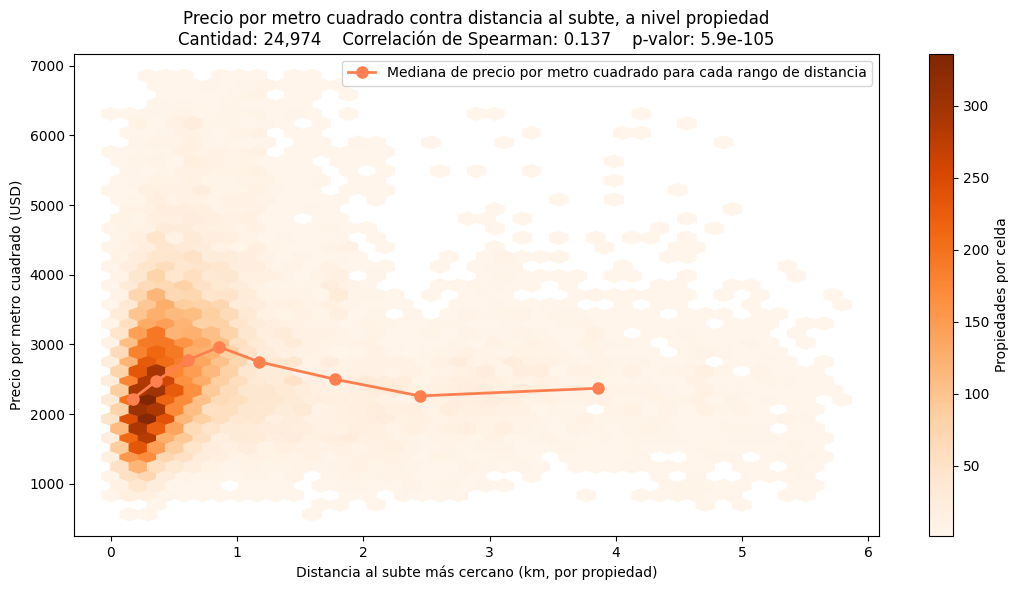

In [13]:
# Visualización a nivel propiedad. Mostramos la densidad con un hexbin
# y encima la mediana por bucket de distancia. Recortamos el uno por ciento
# superior de precios para que la escala se lea bien.
top = subset_h4['precio_por_m2_usd'].quantile(0.99)
plot_data = subset_h4[subset_h4['precio_por_m2_usd'] <= top]

# Para la línea, usamos el centro real de cada bucket (mediana de las distancias
# dentro de ese bucket), no el punto medio geométrico
bucket_med = (plot_data.groupby('bucket_subte', observed=True)
                       .agg(centro_km=('dist_subte_km', 'median'),
                            precio_med=('precio_por_m2_usd', 'median'))
                       .reset_index()
                       .sort_values('centro_km'))

fig, ax = plt.subplots(figsize=(11, 6))
hb = ax.hexbin(plot_data['dist_subte_km'], plot_data['precio_por_m2_usd'],
               gridsize=40, cmap='Oranges', mincnt=1)
fig.colorbar(hb, ax=ax, label='Propiedades por celda')
ax.plot(bucket_med['centro_km'], bucket_med['precio_med'], 'o-',
        color='coral', linewidth=2, markersize=8,
        label='Mediana de precio por metro cuadrado para cada rango de distancia')
ax.set_xlabel('Distancia al subte más cercano (km, por propiedad)')
ax.set_ylabel('Precio por metro cuadrado (USD)')
ax.set_title(f'Precio por metro cuadrado contra distancia al subte, a nivel propiedad\n'
             f'Cantidad: {len(subset_h4):,}    Correlación de Spearman: {rho_h4:.3f}    p-valor: {p_h4:.2g}')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()